# Evaluation on trained models

In [1]:
# mainly loading the environment used for training. Unify everything. (run context)
from evaluation import *
from dirs import *
from train import *

/Users/andrewxu/Documents/GitHub/fiber-image-reconstruction


# Prepare
Manually handle the practical complexity, by loading different trained models and prepare relavant evaluation dataset 

Model: 405_sgm_cam3-without_sensor_noise
Model path: /Users/andrewxu/Desktop/HPC/temp/405_sgm_cam3-without_sensor_noise/model.pt
Config: /Users/andrewxu/Desktop/HPC/temp/405_sgm_cam3-without_sensor_noise/CLEAR26_sgm_cam3.yaml
SQL key: clear26_cam3_to_cam2_eval
Provider column: image_pair
Samples: 217
Batches: 7


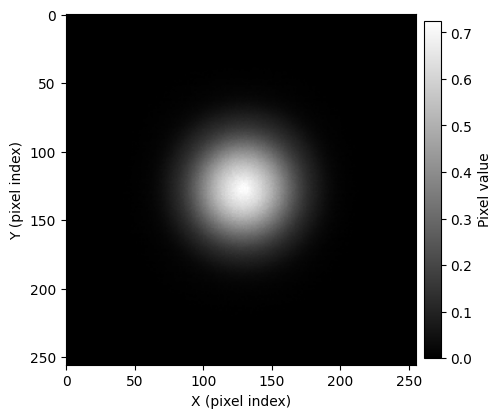

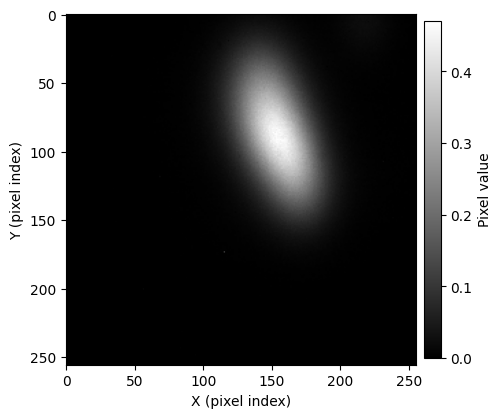

In [2]:
"""CLEAR26 CAE validation on paired real-beam evaluation data."""

# ========================================
# Load model
# ========================================
from copy import deepcopy
from pathlib import Path

import torch
from models.CAE import Autoencoder2D

from config_utils import detect_machine, load_run
from utils import resolve_dataset_dir
from xflow import PyTorchPipeline, SqlProvider, show_model_info
from xflow.data import build_transforms_from_config
from xflow.utils.visualization import plot_image

# Select a run by folder name; the checkpoint and saved config are discovered together.
model_name = "405_sgm_cam3-without_sensor_noise"
# The random baseline reuses this run's saved dataset configuration.
baseline_config_run_name = "baseline_random_predict"
MODEL_NAME = model_name

config_run_name = baseline_config_run_name if model_name == "baseline_random_predict" else model_name
run = load_run(config_run_name, dirs["run_roots"], detect_machine())
config = run["config"]
if model_name == "baseline_random_predict":
    run = {**run, "inference": run["root"] / model_name / "inference"}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

if model_name == "baseline_random_predict":
    model_path = None
    model = torch.nn.Identity()
elif "TM" in model_name:
    from models.TM import TransmissionMatrix

    model_path = run["model"]
    model = TransmissionMatrix.load_model(
        filepath=model_path,
        device=device,
    )
    model.eval()
    print(show_model_info(model))
else:
    model_path = run["model"]
    model = Autoencoder2D.load_model(
        filepath=model_path,
        device=device,
        eval_mode=True,
    )
    print(show_model_info(model))

# ========================================
# Load dataset for inference
# ========================================
dataset_sources = ["processed_405_realbeam_eval_256"]

dataset_dirs = [resolve_dataset_dir(config, src) for src in dataset_sources]
db_rel = config["dataset_structure"]["db"].lstrip("/\\")
db_paths = [d / db_rel for d in dataset_dirs]

eval_sql_key = config["data"].get("eval_sql_key", "clear26_cam1_to_cam2_eval")
provider_output_column = config["data"].get("provider_output_column", "image_pair")
eval_provider = SqlProvider(
    sources={"connection": db_paths[0], "sql": config["sql"][eval_sql_key]},
    output_config={"list": provider_output_column},
)

# Keep cam2 target filenames for CSV/figure metadata. The transform pipeline itself
# still receives the original "input|target" image-pair string from eval_provider.
eval_items = list(eval_provider())
eval_metadata = [Path(str(item).split("|")[-1]).name for item in eval_items]

# Pad absolute parent dirs into both branches of the paired transform.
def set_parent_dir_in_node(node, parent_dir):
    found = False
    if isinstance(node, list):
        for item in node:
            found = set_parent_dir_in_node(item, parent_dir) or found
        return found

    if isinstance(node, dict):
        if node.get("name") == "add_parent_dir":
            node.setdefault("params", {})["parent_dir"] = str(parent_dir)
            found = True

        for value in node.values():
            found = set_parent_dir_in_node(value, parent_dir) or found

    return found

transforms_config = deepcopy(config["data"]["transforms"]["torch"])
if not set_parent_dir_in_node(transforms_config, dataset_dirs[0]):
    raise RuntimeError("No add_parent_dir transform found in CLEAR26 eval transforms.")
transforms = build_transforms_from_config(transforms_config)

# Evaluation should be deterministic; do not mutate the training config.
eval_dataset_ops = deepcopy(config["data"]["dataset_ops"])
for op in eval_dataset_ops:
    if op.get("name") == "torch_batch":
        op.setdefault("params", {})["shuffle"] = False

eval_dataset = PyTorchPipeline(
    eval_provider,
    transforms,
    skip_errors=False,
).to_memory_dataset(eval_dataset_ops)

print("Model:", model_name)
print("Model path:", model_path)
print("Config:", run["snapshot"])
print("SQL key:", eval_sql_key)
print("Provider column:", provider_output_column)
print("Samples:", len(eval_provider))
print("Batches:", len(eval_dataset))

batch = next(iter(eval_dataset))
inputs, targets = batch[:2]
i = 0
plot_image(inputs[i])
plot_image(targets[i])


# Inference
    get and save intermediate result, fixed downstream (mainly plotting) contract
    Completely decoupled, only need a ready to use model and datapipeline that agree the contract, do not care how model and pipeline came

In [ ]:
"""
MMF speckle reconstruction inference with per-sample image triplets saved to disk.

The runner handles iteration, device placement, eval mode, and hooks. The CLEAR26
DataLoader yields (inputs, targets); this cell attaches eval_metadata from the
ordered provider query above so saved figures/CSV rows keep sample names.
"""
import os

from xflow.evaluation.runner import (
    default_unpack_batch,
    run_evaluation,
    TqdmHook,
)
from xflow.extensions.physics.runner import (
    BeamProfileTripletSaverHook,
    BeamParamCSVHook,
    RandomBeamParamCSVHook,
)

save_dir = run["inference"]
os.makedirs(save_dir, exist_ok=True)

_metadata_cursor = {"offset": 0}


def unpack_batch(raw):
    # Backward-compatible path for older notebook datasets shaped as
    # ([inputs, targets], metadata).
    if isinstance(raw, (tuple, list)) and len(raw) == 2:
        payload, maybe_meta = raw
        if isinstance(payload, (tuple, list)) and len(payload) == 2:
            inputs, targets = payload
            return inputs, targets, maybe_meta

    inputs, targets, metadata = default_unpack_batch(raw)
    if metadata is None and "eval_metadata" in globals():
        batch_size = int(inputs.shape[0]) if hasattr(inputs, "shape") and len(inputs.shape) > 0 else 1
        start = _metadata_cursor["offset"]
        stop = start + batch_size
        metadata = eval_metadata[start:stop]
        _metadata_cursor["offset"] = stop
    return inputs, targets, metadata


if model_name == "baseline_random_predict":
    beam_csv = RandomBeamParamCSVHook(
        csv_path=os.path.join(save_dir, "beam_parameters.csv"),
        methods=("moments", "gaussian"),
        append=False,
        flush_every=256,
        seed=42,
        value_range=(0.0, 1.0),
    )
    hooks = [TqdmHook(), beam_csv]
else:
    saver = BeamProfileTripletSaverHook(
        save_dir=save_dir,
        profile_line_width=2.0,
        profile_scale=1.0,  # Set to 0.5 for half-height curves.
    )
    beam_csv = BeamParamCSVHook(
        csv_path=os.path.join(save_dir, "beam_parameters.csv"),
        methods=("moments", "gaussian"),
        append=False,
        flush_every=256,
    )
    hooks = [TqdmHook(), saver, beam_csv]

ctx = run_evaluation(
    model=model,
    dataset=eval_dataset,
    device=device,
    hooks=hooks,
    unpack_batch=unpack_batch,
)

print(f"batches: {ctx.seen_batches}, samples: {ctx.seen_samples}")
print(f"beam parameters saved to: {os.path.join(save_dir, 'beam_parameters.csv')}")

# Visualization
Completely decoupled from above, read only intermediate results with fixed contract, only focus on high quality publication level image, each block is one plot

In [ ]:
"""Specific model to be evaluated, which guides downstream plots/scores to the right folder."""
# Follow the model selected in the CLEAR26 preparation cell above.
MODEL_NAME = model_name

# Optional post-selection hooks for downstream plotting/scoring cells.
# Keep these as None for a clean CLEAR26 evaluation on the prepared eval_dataset.
PREPARED_BEAM_DF = None
CROP_METRICS_DB = None
VALIDATION_FILTER_COLUMN = None
VALIDATION_FILTER_THRESHOLD = None
VALIDATION_FILTER_KEEP = None

# Example optional filter, if a previous block has attached these columns:
# VALIDATION_FILTER_COLUMN = "crop_outside_sum"
# VALIDATION_FILTER_THRESHOLD = 30000
# VALIDATION_FILTER_KEEP = "below"
# CROP_METRICS_DB = "/path/to/metrics.db"


## Classic three statistical plots on testset
(Scatter plot, residual plot and error distribution histogram)

In [ ]:
# Classic three statistical plots on testset
# (Scatter plot, residual plot, and residual histogram)
# Includes centroid, width, and core_sigma -> total 9 plots.

# =========================================================
# Run + save
# =========================================================

# ---- FONT SIZE CONTROLS (final override; nukes evaluation.py defaults) ----

import os
from pathlib import Path
import matplotlib.pyplot as plt
from evaluation import (
    DIMS_TO_USE,
    HIST_BINS,
    HIST_X_RANGE_PCT,
    HIST_Y_MAX,
    PLOT_SPECS,
    PRED_GT_XLIM,
    PRED_GT_YLIM,
    RESIDUAL_SCATTER_XLIM,
    RESIDUAL_SCATTER_YLIM,
    apply_optional_threshold_filter,
    attach_crop_metrics_from_db,
    load_beam_param_df,
    make_three_plots,
    save_fig,
)

LABEL_FONTSIZE  = 14   # axis label text size (xlabel/ylabel)
TICK_FONTSIZE   = 14   # tick label size on both axes
LEGEND_FONTSIZE = 10   # legend text size
import evaluation as _eval
_eval.AXIS_LABEL_SIZE  = LABEL_FONTSIZE
_eval.TICK_LABEL_SIZE  = TICK_FONTSIZE
_eval.LEGEND_FONT_SIZE = LEGEND_FONTSIZE

SCATTER_LEGEND_LOC = "upper left"  # e.g., "upper right"; None keeps default placement
SCATTER_LEGEND_FRAMEON = True  # True = opaque white box; False = no frame; None keeps default
SCALE = 2  # set_aps_double_column scale
SCATTER_LEGEND_FONTSIZE     = LEGEND_FONTSIZE  # text size of scatter-plot legend labels
SCATTER_LEGEND_MARKER_SCALE = 1.5   # multiplier on scatter-marker size in legend
SCATTER_LEGEND_HANDLETEXTPAD = 0.3  # gap between legend marker and label text
HIST_Y_NUM_TICKS            = 4     # max number of y-axis ticks on histogram
SHOW_GRID                   = False  # toggle grid lines on all 3 plots
save_dir = run["inference"]
csv_path = os.path.join(save_dir, "beam_parameters.csv")

def ensure_beam_parameters_csv(csv_path):
    if os.path.exists(csv_path):
        return csv_path

    missing = [name for name in ("model", "eval_dataset", "device") if name not in globals()]
    if missing:
        raise FileNotFoundError(
            f"{csv_path} does not exist, and cannot be generated because {missing} are missing. "
            "Run the CLEAR26 preparation cell first."
        )

    from xflow.evaluation.runner import default_unpack_batch, run_evaluation, TqdmHook
    from xflow.extensions.physics.runner import BeamParamCSVHook

    os.makedirs(os.path.dirname(csv_path), exist_ok=True)
    metadata_cursor = {"offset": 0}

    def unpack_batch_for_metrics(raw):
        inputs, targets, metadata = default_unpack_batch(raw)
        if metadata is None and "eval_metadata" in globals():
            batch_size = int(inputs.shape[0]) if hasattr(inputs, "shape") and len(inputs.shape) > 0 else 1
            start = metadata_cursor["offset"]
            stop = start + batch_size
            metadata = eval_metadata[start:stop]
            metadata_cursor["offset"] = stop
        return inputs, targets, metadata

    ctx = run_evaluation(
        model=model,
        dataset=eval_dataset,
        device=device,
        hooks=[
            TqdmHook(),
            BeamParamCSVHook(
                csv_path=csv_path,
                methods=("moments", "gaussian"),
                append=False,
                flush_every=256,
            ),
        ],
        unpack_batch=unpack_batch_for_metrics,
    )
    print(f"generated beam parameters: {ctx.seen_samples} samples -> {csv_path}")
    return csv_path

if globals().get("PREPARED_BEAM_DF") is not None:
    df = PREPARED_BEAM_DF.copy()
else:
    ensure_beam_parameters_csv(csv_path)
    df = load_beam_param_df(
        csv_path,
        invalid_check_contains=["gaussian", "moments"],
        zero_check_contains=["gaussian", "moments"],
    )

crop_metrics_db = globals().get("CROP_METRICS_DB")
if crop_metrics_db:
    crop_metrics_db = Path(crop_metrics_db).expanduser()
    if not crop_metrics_db.is_file():
        raise FileNotFoundError(f"CROP_METRICS_DB does not exist: {crop_metrics_db}")
    df = attach_crop_metrics_from_db(df, crop_metrics_db)

filter_column = globals().get("VALIDATION_FILTER_COLUMN")
if filter_column is not None:
    if filter_column not in df.columns:
        raise KeyError(
            f"VALIDATION_FILTER_COLUMN={filter_column!r} is not in df. "
            "Attach or prepare those columns before running this plot block."
        )
    df = apply_optional_threshold_filter(
        df,
        target_column=filter_column,
        threshold=VALIDATION_FILTER_THRESHOLD,
        keep=VALIDATION_FILTER_KEEP,
    )

for param_type, fit_method in PLOT_SPECS:
    fig1, fig2, fig3 = make_three_plots(
        df=df,
        param_type=param_type,
        fit_method=fit_method,
        dims=DIMS_TO_USE,
        pred_gt_xlim=PRED_GT_XLIM,
        pred_gt_ylim=PRED_GT_YLIM,
        residual_xlim=RESIDUAL_SCATTER_XLIM,
        residual_ylim=RESIDUAL_SCATTER_YLIM,
        hist_x_range_pct=HIST_X_RANGE_PCT,
        hist_bins=HIST_BINS,
        hist_y_max=HIST_Y_MAX,
        scale=SCALE,
        scatter_legend_fontsize=SCATTER_LEGEND_FONTSIZE,
        scatter_legend_marker_scale=SCATTER_LEGEND_MARKER_SCALE,
        scatter_legend_handletextpad=SCATTER_LEGEND_HANDLETEXTPAD,
        hist_y_num_ticks=HIST_Y_NUM_TICKS,
    )

    # Final tick-size override on every axis (priority over any per-call defaults).
    for _fig in (fig1, fig2, fig3):
        for ax in _fig.axes:
            ax.tick_params(axis="both", which="major", labelsize=TICK_FONTSIZE)
            ax.tick_params(axis="both", which="minor", labelsize=TICK_FONTSIZE)

    if SCATTER_LEGEND_LOC is not None or SCATTER_LEGEND_FRAMEON is not None:
        for ax in fig1.axes:
            leg = ax.get_legend()
            if leg is None:
                continue
            if SCATTER_LEGEND_LOC is not None:
                ax.legend(loc=SCATTER_LEGEND_LOC,
                          fontsize=SCATTER_LEGEND_FONTSIZE,
                          markerscale=SCATTER_LEGEND_MARKER_SCALE,
                          handletextpad=SCATTER_LEGEND_HANDLETEXTPAD)
                leg = ax.get_legend()
            if SCATTER_LEGEND_FRAMEON is not None:
                leg.set_frame_on(SCATTER_LEGEND_FRAMEON)
                if SCATTER_LEGEND_FRAMEON:
                    leg.get_frame().set_facecolor("white")
                    leg.get_frame().set_alpha(1.0)

    for _fig in (fig1, fig2, fig3):
        for ax in _fig.axes:
            if SHOW_GRID:
                ax.grid(True, linestyle="--")
                ax.set_axisbelow(True)
            else:
                ax.grid(False)

    tag = f"{fit_method}_{param_type}" if fit_method else param_type

    save_fig(fig1, os.path.join(save_dir, f"{SAVE_PREFIX}{tag}_scatter_pred_vs_gt"))
    save_fig(fig2, os.path.join(save_dir, f"{SAVE_PREFIX}{tag}_scatter_residual_vs_gt"))
    save_fig(fig3, os.path.join(save_dir, f"{SAVE_PREFIX}{tag}_hist_residual_percent"))

    plt.close(fig1)
    plt.close(fig2)
    plt.close(fig3)


## Error distribution correlation with both parameters
Hexegon plot of error shade on each parameter distribution

In [ ]:

import os
from pathlib import Path
from evaluation import (
    add_gaussian_error_columns,
    apply_optional_threshold_filter,
    attach_crop_metrics_from_db,
    drop_invalid_rows,
    load_beam_param_df,
    plot_hex_error_2d,
    save_fig,
)

gridsize = 30
range_mode = "full"   # "full" or "tight"
SCALE = 1.0  # set_aps_double_column scale
SAVE_PREFIX = "_"

save_dir = run["inference"]
csv_path = os.path.join(save_dir, "beam_parameters.csv")

df = load_beam_param_df(
    csv_path,
    invalid_check_contains=["gaussian", "moments"],
    zero_check_contains=["gaussian", "moments"],
)

# Attach crop intensity metrics from the saved metrics DB.
# Adds columns: crop_inside_sum, crop_outside_sum, crop_outside_inside_ratio.
df = attach_crop_metrics_from_db(
    df,
    run["root"] / Path(dirs["merged_db_path"]).name,
)

# Keep only rows with filter
df = apply_optional_threshold_filter(
    df,
    target_column=VALIDATION_FILTER_COLUMN,   
    threshold=VALIDATION_FILTER_THRESHOLD, 
    keep=VALIDATION_FILTER_KEEP,
)

df = add_gaussian_error_columns(df)
df = drop_invalid_rows(df, check_contains=["gaussian", "moments"])   # blanket clean: drop any row with NaN/inf anywhere

fig_c, _ = plot_hex_error_2d(df, param_type="centroid", gridsize=gridsize, range_mode=range_mode, scale=SCALE)
fig_w, _ = plot_hex_error_2d(df, param_type="width",    gridsize=gridsize, range_mode=range_mode, scale=SCALE)

save_fig(fig_c, os.path.join(save_dir, f"{SAVE_PREFIX}gaussian_centroid_hex_error"), bbox_inches="tight")
save_fig(fig_w, os.path.join(save_dir, f"{SAVE_PREFIX}gaussian_width_hex_error"), bbox_inches="tight")


# Error distribution histogram

In [ ]:

import os
from pathlib import Path
import matplotlib.pyplot as plt
from evaluation import (
    DIMS_TO_USE,
    PLOT_SPECS,
    apply_optional_threshold_filter,
    attach_crop_metrics_from_db,
    load_beam_param_df,
    plot_residual_hist_pct,
    prepare_plot_df,
    save_fig,
)

SAVE_PREFIX = "_"

# ---- FONT SIZE CONTROLS (final override; nukes evaluation.py defaults) ----
LABEL_FONTSIZE  = 14   # axis label text size (xlabel/ylabel)
TICK_FONTSIZE   = 14   # tick label size on both axes
LEGEND_FONTSIZE = 10   # legend text size
import evaluation as _eval
_eval.AXIS_LABEL_SIZE  = LABEL_FONTSIZE
_eval.TICK_LABEL_SIZE  = TICK_FONTSIZE
_eval.LEGEND_FONT_SIZE = LEGEND_FONTSIZE

# Single-plot controls (override the module defaults for THIS cell only)
# BINS            = 50                # number of histogram bins
# X_RANGE         = (-20.0, 20.0)     # symmetric x range in % (residual)
# Y_MAX           = 250              # y-axis max; None = auto
# LEGEND_FRAMEON  = True              # True = white box w/ black border; False = transparent, no frame

BINS            = 400                # number of histogram bins
X_RANGE         = (-20.0, 20.0)     # symmetric x range in % (residual)
Y_MAX           = 140              # y-axis max; None = auto
LEGEND_FRAMEON  = True             # transparent legend, no bounding box
SCALE           = 2              # set_aps_double_column scale
Y_NUM_TICKS     = 6                 # max number of y-axis ticks
SHOW_GRID       = True              # toggle grid lines on the histogram

save_dir = run["inference"]
csv_path = os.path.join(save_dir, "beam_parameters.csv")

df = load_beam_param_df(
    csv_path,
    invalid_check_contains=["gaussian", "moments"],
    zero_check_contains=["gaussian", "moments"],
)

# Attach crop intensity metrics from the saved metrics DB.
df = attach_crop_metrics_from_db(
    df,
    run["root"] / Path(dirs["merged_db_path"]).name,
)

# Keep only rows with filter
df = apply_optional_threshold_filter(
    df,
    target_column=VALIDATION_FILTER_COLUMN,
    threshold=VALIDATION_FILTER_THRESHOLD,
    keep=VALIDATION_FILTER_KEEP,
)

for param_type, fit_method in PLOT_SPECS:
    clean_df, active_dims = prepare_plot_df(
        df=df, param_type=param_type, fit_method=fit_method, dims=DIMS_TO_USE,
    )
    fig, _ = plot_residual_hist_pct(
        clean_df,
        param_type=param_type, fit_method=fit_method, dims=active_dims,
        x_range_pct=X_RANGE,
        bins=BINS,
        y_max=Y_MAX,
        x_coverage_pct=None,   # disable adaptive coverage so X_RANGE is honored
        annotate_stats=True,
        annotate_loc="upper right",
        legend_fontsize=LEGEND_FONTSIZE,
        legend_frameon=LEGEND_FRAMEON,
        scale=SCALE,
        y_num_ticks=Y_NUM_TICKS,
    )

    # Final tick-size override on every axis (priority over any per-call defaults).
    for ax in fig.axes:
        ax.tick_params(axis="both", which="major", labelsize=TICK_FONTSIZE)
        ax.tick_params(axis="both", which="minor", labelsize=TICK_FONTSIZE)
        if SHOW_GRID:
            ax.grid(True, linestyle="--")
            ax.set_axisbelow(True)
        else:
            ax.grid(False)

    tag = f"{fit_method}_{param_type}" if fit_method else param_type
    save_fig(fig, os.path.join(save_dir, f"{SAVE_PREFIX}{tag}_hist_residual_percent"))
    plt.close(fig)


# Statistical overview of entire testset

In [ ]:
"""Final score/statistics from the upstream beam-parameter CSV.

Input contract:
- run["inference"] is derived from the selected run folder
- beam_parameters.csv is produced by the inference cell above
- PREPARED_BEAM_DF can optionally override the CSV with an already-prepared dataframe
- CROP_METRICS_DB and VALIDATION_FILTER_* are optional post-selection hooks

Output:
- _fit_metrics.json in the same inference folder
"""

from evaluation import (
    apply_optional_threshold_filter,
    attach_crop_metrics_from_db,
    compute_fit_and_image_metrics,
    drop_invalid_rows,
    load_beam_param_df,
)

import json
import os
from pathlib import Path

SAVE_PREFIX = globals().get("SAVE_PREFIX", "_")
save_dir = run["inference"]
csv_path = os.path.join(save_dir, "beam_parameters.csv")
metrics_path = os.path.join(save_dir, f"{SAVE_PREFIX}fit_metrics.json")


def load_score_dataframe(csv_path):
    prepared_df = globals().get("PREPARED_BEAM_DF")
    if prepared_df is not None:
        return prepared_df.copy(), "PREPARED_BEAM_DF"

    if not os.path.isfile(csv_path):
        raise FileNotFoundError(
            f"Missing upstream beam-parameter file: {csv_path}. "
            "Run the inference cell first, or set PREPARED_BEAM_DF."
        )

    return load_beam_param_df(
        csv_path,
        invalid_check_contains=["gaussian", "moments"],
        zero_check_contains=["gaussian", "moments"],
    ), csv_path


df, score_source = load_score_dataframe(csv_path)

crop_metrics_db = globals().get("CROP_METRICS_DB")
if crop_metrics_db:
    crop_metrics_db = Path(crop_metrics_db).expanduser()
    if not crop_metrics_db.is_file():
        raise FileNotFoundError(f"CROP_METRICS_DB does not exist: {crop_metrics_db}")
    df = attach_crop_metrics_from_db(df, crop_metrics_db)

filter_column = globals().get("VALIDATION_FILTER_COLUMN")
if filter_column is not None:
    if filter_column not in df.columns:
        raise KeyError(
            f"VALIDATION_FILTER_COLUMN={filter_column!r} is not in df. "
            "Attach or prepare those columns before running the score block."
        )
    df = apply_optional_threshold_filter(
        df,
        target_column=filter_column,
        threshold=VALIDATION_FILTER_THRESHOLD,
        keep=VALIDATION_FILTER_KEEP,
    )

df = drop_invalid_rows(df, check_contains=["gaussian", "moments"])
print(f"Score source: {score_source}")
print(f"Valid samples for metric computation: {len(df)}")

metrics_dict = compute_fit_and_image_metrics(
    df,
    fit_methods=("gaussian", "moments"),
    metrics=("rmse", "mae", "r2", "mse"),
    image_cols={
        "reconstructed_label_psnr": "image_psnr",
        "reconstructed_label_ssim": "image_ssim",
        "reconstructed_label_mae": "image_pixelmae",
    },
    image_agg="mean",
    save_path=metrics_path,
)

# Aggregate gaussian transverse params (h/v x centroid/width) into single MAE/RMSE.
_keys = [
    "gaussian_h_centroid",
    "gaussian_v_centroid",
    "gaussian_h_width",
    "gaussian_v_width",
]
for _m in ("mae", "rmse"):
    metrics_dict[f"gaussian_{_m}"] = sum(metrics_dict[f"{k}_{_m}"] for k in _keys) / len(_keys)

with open(metrics_path, "w", encoding="utf-8") as f:
    json.dump(metrics_dict, f, indent=2)

print(f"Metrics saved to: {metrics_path}")
print("gaussian RMSE:", metrics_dict["gaussian_rmse"], "gaussian MAE:", metrics_dict["gaussian_mae"])
metrics_dict


# Cross model summary
this part read final statistics across different run and give a final conclusion

In [ ]:
from pathlib import Path
import json
import pandas as pd
from xflow.utils.io import scan_files
from typing import Callable, Iterable, Optional

# -----------------------------
# 1. Aggregation / padding layer
# -----------------------------

def _infer_fit_metrics(columns: Iterable[str], methods: Iterable[str]) -> list[str]:
    """Infer available metric suffixes from fit-parameter columns."""
    metrics = set()

    for col in columns:
        for method in methods:
            prefix_parts = [
                f"{method}_h_centroid_",
                f"{method}_v_centroid_",
                f"{method}_h_width_",
                f"{method}_v_width_",
            ]

            for prefix in prefix_parts:
                if col.startswith(prefix):
                    metrics.add(col.removeprefix(prefix))

    return sorted(metrics)


def _check_columns(df: pd.DataFrame, columns: Iterable[str], strict: bool) -> None:
    missing = [c for c in columns if c not in df.columns]

    if strict and missing:
        raise KeyError(f"Missing expected columns: {missing}")


def add_fit_metric_aggregates(
    df: pd.DataFrame,
    methods: Iterable[str] = ("gaussian",),
    metrics: Optional[Iterable[str]] = None,
    strict: bool = True,
) -> pd.DataFrame:
    """Return a new dataframe with aggregate fit-metric columns.

    Expected input columns:

        {method}_{axis}_{parameter}_{metric}

    Examples:
        gaussian_h_centroid_rmse
        gaussian_v_centroid_rmse
        gaussian_h_width_rmse
        gaussian_v_width_rmse

    Added columns:
        {method}_centroid_{metric}
        {method}_width_{metric}
        {method}_{metric}
    """
    out = df.copy(deep=True)

    if metrics is None:
        metrics = _infer_fit_metrics(out.columns, methods)

    for method in methods:
        for metric in metrics:
            centroid_cols = [
                f"{method}_h_centroid_{metric}",
                f"{method}_v_centroid_{metric}",
            ]
            width_cols = [
                f"{method}_h_width_{metric}",
                f"{method}_v_width_{metric}",
            ]
            all_cols = centroid_cols + width_cols

            _check_columns(out, all_cols, strict=strict)

            available_centroid_cols = [c for c in centroid_cols if c in out.columns]
            available_width_cols = [c for c in width_cols if c in out.columns]
            available_all_cols = [c for c in all_cols if c in out.columns]

            if available_centroid_cols:
                out[f"{method}_centroid_{metric}"] = out[available_centroid_cols].mean(axis=1)

            if available_width_cols:
                out[f"{method}_width_{metric}"] = out[available_width_cols].mean(axis=1)

            if available_all_cols:
                out[f"{method}_{metric}"] = out[available_all_cols].mean(axis=1)

    return out

def collect_fit_metrics(
    root_dir,
    save_csv=True,
    csv_name="cross_model_fit_metrics_summary.csv",
):
    root_dir = Path(root_dir)

    all_json = scan_files(root_dir, extensions=".json", return_type="path", recursive=True)
    metric_files = [Path(p) for p in all_json if Path(p).name == "_fit_metrics.json"]

    rows = []
    for fp in metric_files:
        with open(fp, "r", encoding="utf-8") as f:
            row = json.load(f)  # assumes same keys across all files
        row["model"] = fp.parent.parent.name  # .../<model>/inference/_fit_metrics.json
        rows.append(row)

    if not rows:
        return pd.DataFrame()

    df = pd.DataFrame(rows).set_index("model").sort_index()
    df = add_fit_metric_aggregates(
        df,
        methods=("gaussian",),    #gaussian , "moments"
        metrics=("rmse", "mae", "r2"),
    )
    if save_csv:
        out_csv = root_dir / csv_name
        df.to_csv(out_csv, index=True)
        print(f"Saved CSV: {out_csv}")

    return df

# usage

root_dir = run["root"]
df = collect_fit_metrics(root_dir)
df

# Cross model performance visualization

saved /Users/andrewxu/Desktop/HPC/temp/cross_model_bars_fit_absolute_error.pdf


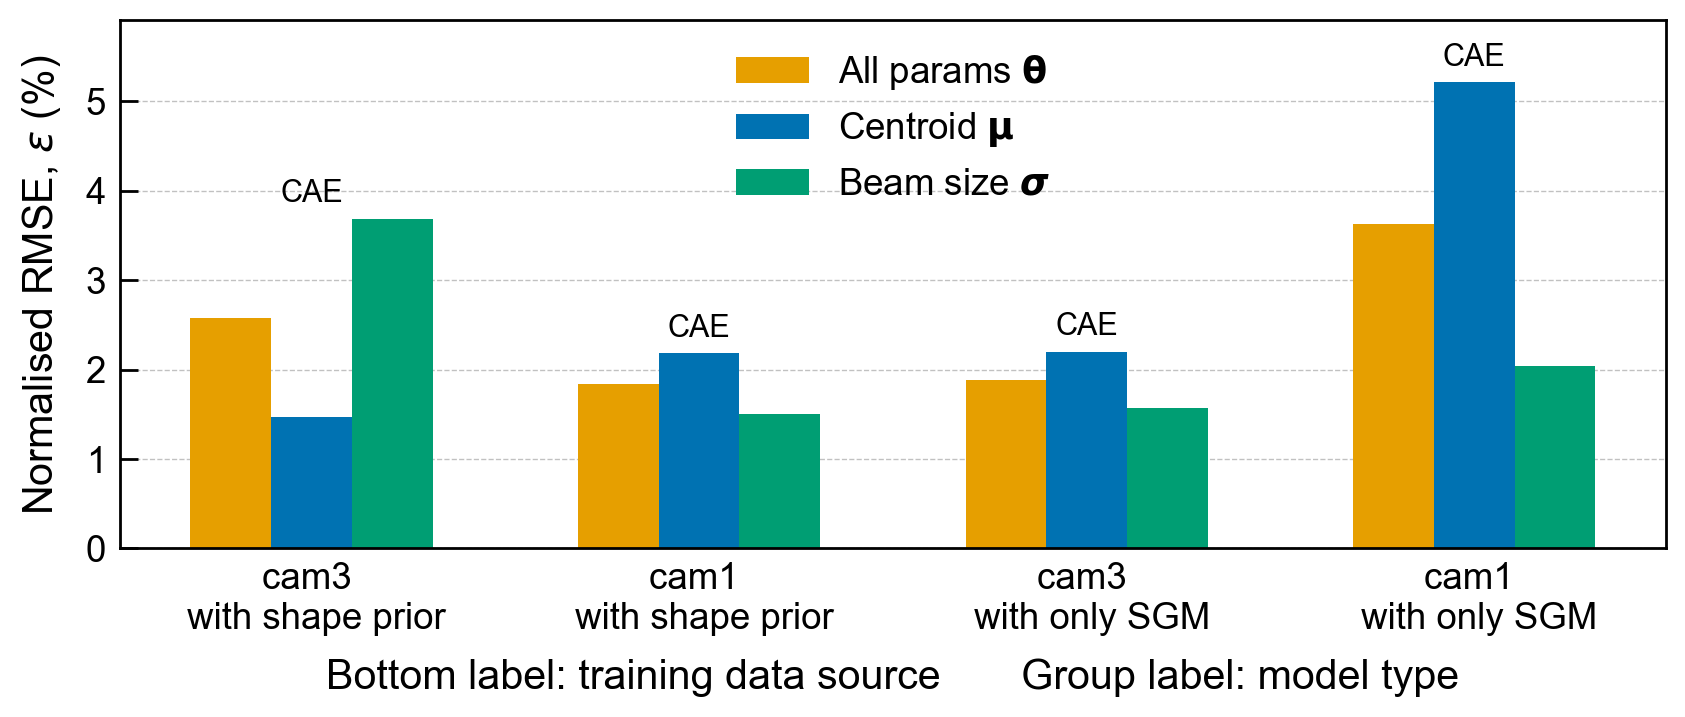

In [3]:
from __future__ import annotations

# Inline render: high-res raster PNG (retina = 2x DPI). Transparency is forced
# at the bottom by setting fig/ax patch alpha = 0 -- InlineBackend.print_figure_kwargs
# is unreliable across formats, and set_aps_style resets facecolors anyway.
%config InlineBackend.figure_format = 'retina'

from collections import OrderedDict
from pathlib import Path
from typing import Callable, Iterable, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from dirs import *
from evaluation import save_fig
from xflow.extensions.style.aps import set_aps_double_column as set_aps_style


# -----------------------------
# 1. Column-existence helper
# -----------------------------

def _check_columns(df: pd.DataFrame, columns: Iterable[str], strict: bool) -> None:
    missing = [c for c in columns if c not in df.columns]
    if strict and missing:
        raise KeyError(f"Missing expected columns: {missing}")


# -----------------------------
# 2. Metric scale grouping layer
# -----------------------------

def group_metrics_by_scale(metrics: Iterable[str]) -> OrderedDict[str, list[str]]:
    """Group metric columns that can reasonably share one y-axis."""
    groups: OrderedDict[str, list[str]] = OrderedDict()

    for metric in metrics:
        scale_key = infer_metric_scale(metric)
        groups.setdefault(scale_key, []).append(metric)

    return groups


def infer_metric_scale(metric: str) -> str:
    """Infer which y-scale family a metric belongs to."""
    metric_lower = metric.lower()

    if metric_lower.endswith("_r2"):
        return "r2"

    if metric_lower.endswith("_mse"):
        return "mse"

    if (
        metric_lower.endswith("_rmse")
        or metric_lower.endswith("_mae")
        or metric_lower.endswith("_medae")
        or metric_lower.endswith("_max_error")
    ):
        if metric_lower.startswith("image_"):
            return "image_absolute_error"
        return "fit_absolute_error"

    if metric_lower == "image_pixelmae":
        return "image_absolute_error"

    if metric_lower == "image_ssim":
        return "ssim"

    if metric_lower == "image_psnr":
        return "psnr_db"

    return "other"


# -----------------------------
# 3. Ranking layer
# -----------------------------

def infer_higher_is_better(metric: str) -> bool:
    """Infer whether larger values are better for a metric."""
    metric_lower = metric.lower()

    higher_better_metrics = (
        "_r2",
        "_ssim",
        "_psnr",
    )

    lower_better_metrics = (
        "_mse",
        "_rmse",
        "_mae",
        "_medae",
        "_max_error",
        "pixelmae",
    )

    if metric_lower.endswith(higher_better_metrics):
        return True

    if metric_lower.endswith(lower_better_metrics) or "pixelmae" in metric_lower:
        return False

    # Conservative default: lower is better for unknown error-like values.
    return False


def sort_by_metric(
    df: pd.DataFrame,
    metric: str,
    higher_is_better: Optional[bool] = None,
) -> pd.DataFrame:
    """Return a new dataframe sorted best-to-worst by one metric."""
    if higher_is_better is None:
        higher_is_better = infer_higher_is_better(metric)

    return df.sort_values(
        by=metric,
        ascending=not higher_is_better,
        na_position="last",
    ).copy(deep=True)


# -----------------------------
# 4. Plotting layer
# -----------------------------

def plot_metric_bars(
    df: pd.DataFrame,
    metrics: list[str],
    model_col: str = "model",
    model_order: Optional[list[str]] = None,
    model_label_map: Optional[dict[str, str]] = None,
    metric_label_map: Optional[dict[str, str]] = None,
    split_by_scale: bool = True,
    rank_models: bool = False,
    rank_by: Optional[str] = None,
    higher_is_better: Optional[dict[str, bool]] = None,
    style_func: Optional[Callable[[], None]] = None,
    figsize: tuple[float, float] = (7.2, 3.8),
    rotation: int = 35,
    group_spacing: float = 1.0,
    xtick_ha: str = "right",
    hgrid: bool = False,
) -> list[tuple[plt.Figure, plt.Axes]]:
    """Plot grouped bar charts for selected metrics.

    Ranking logic:
        - If model_order is provided, use model_order.
        - Else if rank_models=True, rank each plot by rank_by.
        - If rank_by=None, rank by the first metric in that plot.
    """
    metrics = [m for m in metrics if m]  # remove empty placeholders like ""

    if not metrics:
        raise ValueError("No valid metrics were provided.")

    plot_df = df.copy(deep=True)

    # Allow model names to be stored as index.
    if model_col not in plot_df.columns:
        if plot_df.index.name == model_col:
            plot_df = plot_df.reset_index()
        else:
            raise KeyError(
                f"Missing model column '{model_col}'. "
                f"Available columns: {list(plot_df.columns)}. "
                f"Index name: {plot_df.index.name}"
            )

    _check_columns(plot_df, [model_col] + metrics, strict=True)

    if model_order is not None:
        plot_df[model_col] = pd.Categorical(
            plot_df[model_col],
            categories=model_order,
            ordered=True,
        )
        plot_df = plot_df.sort_values(model_col)

    if split_by_scale:
        metric_groups = group_metrics_by_scale(metrics)
    else:
        metric_groups = OrderedDict({"selected_metrics": metrics})

    figs_axes = []

    for scale_key, group_metrics in metric_groups.items():
        this_plot_df = plot_df.copy(deep=True)

        if model_order is None and rank_models:
            this_rank_metric = rank_by or group_metrics[0]

            if this_rank_metric not in this_plot_df.columns:
                raise KeyError(f"Ranking metric not found: {this_rank_metric}")

            metric_higher_is_better = None
            if higher_is_better is not None:
                metric_higher_is_better = higher_is_better.get(this_rank_metric)

            this_plot_df = sort_by_metric(
                this_plot_df,
                metric=this_rank_metric,
                higher_is_better=metric_higher_is_better,
            )

        # Apply APS style per figure (matches evaluation.py's _new_ax convention).
        if style_func is not None:
            style_func()
        # Scale figure width with group_spacing: x-positions stretch in data
        # units, so the figure must stretch in inches too -- otherwise the
        # bars just compress and x-tick labels stay squeezed together.
        scaled_figsize = (figsize[0] * max(group_spacing, 1e-6), figsize[1])
        fig, ax = plt.subplots(figsize=scaled_figsize)

        _plot_one_grouped_bar_chart(
            ax=ax,
            df=this_plot_df,
            metrics=group_metrics,
            model_col=model_col,
            model_label_map=model_label_map,
            metric_label_map=metric_label_map,
            group_spacing=group_spacing,
            xtick_ha=xtick_ha,
        )

        ax.set_ylabel(_default_ylabel(scale_key))
        if scale_key == "r2":
            _clip_r2_axis_at_zero(ax, this_plot_df, group_metrics)

        ax.set_xlabel("")
        ax.tick_params(axis="x", rotation=rotation)
        # ax.legend(
        #     frameon=True,
        #     framealpha=0.9,
        #     facecolor="white",
        #     edgecolor="0.8",
        # )
        ax.legend(frameon=False)

        if hgrid:
            # Faint dashed horizontal gridlines drawn behind the bars.
            ax.yaxis.grid(True, linestyle="--", linewidth=0.5, color="0.6", alpha=0.6)
            ax.set_axisbelow(True)

        fig.tight_layout()

        figs_axes.append((fig, ax))

    return figs_axes


def _plot_one_grouped_bar_chart(
    ax: plt.Axes,
    df: pd.DataFrame,
    metrics: list[str],
    model_col: str,
    model_label_map: Optional[dict[str, str]],
    metric_label_map: Optional[dict[str, str]],
    group_spacing: float = 1.0,
    xtick_ha: str = "right",
) -> None:
    # group_spacing scales the distance between group centers (1.0 = current),
    # while bar_width within a group stays fixed -- so larger spacing = bigger gap.
    x = np.arange(len(df)) * group_spacing
    n_metrics = len(metrics)
    bar_width = min(0.8 / max(n_metrics, 1), 0.25)

    model_labels = df[model_col].astype(str).tolist()
    if model_label_map is not None:
        model_labels = [model_label_map.get(name, name) for name in model_labels]

    offsets = (np.arange(n_metrics) - (n_metrics - 1) / 2) * bar_width

    for i, metric in enumerate(metrics):
        label = metric_label_map.get(metric, metric) if metric_label_map else metric

        ax.bar(
            x + offsets[i],
            df[metric].to_numpy(dtype=float),
            width=bar_width,
            label=label,
        )

    ax.set_xticks(x)
    ax.set_xticklabels(model_labels, ha=xtick_ha)


def _clip_r2_axis_at_zero(
    ax: plt.Axes,
    df: pd.DataFrame,
    metrics: list[str],
) -> None:
    """Keep R2 plots on the meaningful 0-to-1 comparison scale."""
    values = df[metrics].to_numpy(dtype=float)
    has_negative_r2 = np.isfinite(values).any() and np.nanmin(values) < 0

    ax.axhline(0, color="0.25", linewidth=0.6)
    ax.set_ylim(0, 1)

    if has_negative_r2:
        ax.text(
            0.01,
            0.98,
            r"Negative $R^2$ values clipped below 0.",
            transform=ax.transAxes,
            ha="left",
            va="top",
            fontsize="small",
            color="0.35",
        )


def _default_ylabel(scale_key: str) -> str:
    labels = {
        "fit_absolute_error": r"Normalised RMSE, $\epsilon$ (%)",
        "image_absolute_error": "Image absolute error",
        "mse": "MSE",
        "r2": r"$R^2$",
        "ssim": "SSIM",
        "psnr_db": "PSNR [dB]",
        "other": "Value",
        "selected_metrics": "Value",
    }
    return labels.get(scale_key, "Value")


# -----------------------------
# 5. Standalone usage (reads CSV from disk, optional PDF save back to disk)
# -----------------------------

# Read aggregated cross-model metrics straight from the saved CSV. This block
# is fully decoupled from any earlier cell.
SUMMARY_DIR = run["root"]
SUMMARY_CSV = SUMMARY_DIR / "cross_model_fit_metrics_summary.csv"

df_plot = pd.read_csv(SUMMARY_CSV)
if "model" not in df_plot.columns:
    df_plot = df_plot.reset_index()  # safety net: in case "model" was written as the index

# Pick which models to include and the x-tick label for each.
# Same shape as the loop cell's MODELS dict, but the per-model metadata is
# a display "label" (used for the x-tick) instead of a "filter" flag.
# Comment out a row to drop that model from the plot.
MODELS = {
    # "chromox_cae_random_scan":                          {"label": "chromox_cae_random_scan"},
    # CAE trained using line-scan localized responses + mixed CLEAR/SGM profile weights
    # "chromox_cropped_cae_line_scan_mixture": {"label": "Mixed + \nraster basis", "model": "CAE"},  #  "Line + mixed\nimage"
    # "chromox_cropped_cae_line_scan_mixture_prab_model": {"label": "chromox_cropped_cae_line_scan_mixture_prab_model"},
    # CAE trained using line-scan localized responses + SGM-generated profile weights
    # "chromox_cropped_cae_line_scan_sgm": {"label": "SGM + \nraster basis", "model": "CAE"},  #  "Line + SGM\nimage"
    # CAE trained using line-scan localized responses + measured CLEAR beam profile weights
    # Treat as a matched-profile / upper-bound comparison if profiles come from the test-set distribution
    # "chromox_cropped_cae_line_scan_real_beam_image": {"label": "Beam image + \nraster basis", "model": "CAE"},  # "Line + beam\nimage"
    # "chromox_cropped_cae_random_scan":                  {"label": "chromox_cropped_cae_random_scan"},
    # CAE trained/tested using a split of the random-position CLEAR scan dataset 
    # "chromox_cropped_cae_random_scan_leakless": {"label": "Random \nscan data", "model": "CAE"},  # "Random-pos.\nsplit"
    # Transmission-matrix baseline using the line-scan basis
    # "chromox_cropped_TM_line_scan": {"label": "Raster scan \nbasis", "model": "TM"},  # "TM\n(line basis)"
    # "chromox_cropped_cae_line_scan":                    {"label": "line scan multi-sample"},
    # CAE trained directly on the vanilla line-scan basis, without recombined beam-profile patterns
    # "chromox_cropped_cae_line_scan_single_sample": {"label": "Raster scan \nbasis", "model": "CAE"},   # "Line-scan\nbasis only"
    # "Model_trained_on_CHROMOX_only":                    {"label": "Model_trained_on_CHROMOX_only"},
    # "Model_trained_on_CHROMOX_LASER_only":              {"label": "Model_trained_on_CHROMOX_LASER_only"},
    # Laboratory DMD validation using line-scan basis + SGM-generated profiles
    # "Model_trained_on_DMD_orth_SGM_inLab_150MB": {"label": "Lab DMD\n+ SGM"},
    # "clear_dmd_cae_line_scan_sgm":                      {"label": "clear_dmd_cae_line_scan_sgm"},
    # Randomly generated beam parameters within the valid range
    "baseline_random_predict": {"label": "No training \ndata", "model": "Random Predictor"},  # "Random-param.\nbaseline"
    
    "405_cam1_with_beam_prior": {"label": "cam1 \n with shape prior", "model": "CAE"},
    "405_cam3_with_beam_prior": {"label": "cam3 \n with shape prior", "model": "CAE"},
    "405_sgm_cam1-20260716142907": {"label": "cam1 \n with only SGM", "model": "CAE"},
    "405_sgm_cam3-optimized_SGM": {"label": "cam3 \n with only SGM", "model": "CAE"},
}

df_plot = df_plot[df_plot["model"].isin(MODELS)].copy()
model_label_map = {k: v["label"] for k, v in MODELS.items()}
model_top_label_map = {k: v["model"] for k, v in MODELS.items()}

# Each entry is metric_key -> (legend alias, bar color). Empty string = skip.
metrics_to_plot = {
    "gaussian_rmse":          (r"All params $\mathbf{\theta}$",              "#E69F00"),  # #E69F00
    "gaussian_centroid_rmse": (r"Centroid $\mathbf{\mu}$",              "#0072B2"),
    "gaussian_width_rmse":    (r"Beam size $\boldsymbol{\sigma}$",      "#009E73"),
    
    # "gaussian_mae":           "",
    # "gaussian_centroid_mae":  "",
    # "gaussian_width_mae":     "",

    # "gaussian_r2":            "",
    # "gaussian_centroid_r2":   "",
    # "gaussian_width_r2":      "",
    # "image_ssim":             "",
    # "image_psnr":             "",
    # "image_pixelmae":         "",
}
metric_label_map = {k: v[0] for k, v in metrics_to_plot.items() if v}
metric_color_map = {v[0]: v[1] for v in metrics_to_plot.values() if v}

# Convert normalised RMSE values to percentages (×100) so the y-axis reads in %.
df_plot[list(metrics_to_plot)] = df_plot[list(metrics_to_plot)] * 100

figs_axes = plot_metric_bars(
    df_plot,
    metrics=list(metrics_to_plot),
    model_col="model",
    rank_models=True,
    style_func=set_aps_style(scale=1.65, legend_background=True),
    rank_by="gaussian_mae",  # gaussian_rmse, gaussian_mae
    model_label_map=model_label_map,
    metric_label_map=metric_label_map,
    rotation=0,
    group_spacing=1.2,        # >1.0 spreads groups apart AND widens the figure (room for x-tick labels)
    xtick_ha="center",        # "left" | "center" | "right" (Word-style alignment)
    hgrid=True,               # faint dashed horizontal gridlines behind the bars
)

# Force transparent figure & axes backgrounds for the inline retina-PNG render.
ordered_models = df_plot.sort_values("gaussian_mae")["model"].tolist()
y_headroom = 0.08  # extra empty space above bars (fraction of axis range)
for fig, ax in figs_axes:
    fig.patch.set_alpha(0)
    ax.patch.set_alpha(0)
    for container in ax.containers:
        c = metric_color_map.get(container.get_label())
        if c is not None:
            for bar in container:
                bar.set_facecolor(c)
    ax.legend(frameon=False)
    ymin, ymax = ax.get_ylim()
    ymax = ymax + (ymax - ymin) * y_headroom
    ax.set_ylim(ymin, ymax)
    pad = (ymax - ymin) * 0.02
    for i, (xi, key) in enumerate(zip(ax.get_xticks(), ordered_models)):
        top = model_top_label_map.get(key, "")
        if top:
            h = max(c[i].get_height() for c in ax.containers)
            ax.text(xi, h + pad, top, ha="center", va="bottom", fontsize="small")

# Add xlabel to the first bar plot only.
if figs_axes:
    first_fig, first_ax = figs_axes[0]
    first_ax.set_xlabel("Bottom label: training data source       Group label: model type")
    first_fig.tight_layout()

# Optional: write each panel as a transparent PDF next to the summary CSV.
# Flip SAVE = True after reviewing inline; one PDF per metric-scale panel,
# named cross_model_bars_<scale_key>.pdf in the selected run root.
SAVE = True
if SAVE:
    scale_keys = list(group_metrics_by_scale(metrics_to_plot).keys())
    for scale_key, (fig, _) in zip(scale_keys, figs_axes):
        save_fig(fig, str(SUMMARY_DIR / f"cross_model_bars_{scale_key}"))
        print(f"saved {SUMMARY_DIR / f'cross_model_bars_{scale_key}.pdf'}")


# Plot single sample orignal and reconstruction image with profile, then MMF output
Need to run the block to prepare ready to use Model and Pipeline

In [ ]:
# ========================================
# Load model
# ========================================
import torch
from models.CAE import Autoencoder2D
from config_utils import detect_machine, load_run

model_name = "chromox_cropped_cae_line_scan_real_beam_image"
run = load_run(model_name, dirs["run_roots"], detect_machine())

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

if "TM" in model_name:
    from models.TM import TransmissionMatrix
    model_path = run["model"]
    model = TransmissionMatrix.load_model(
        filepath=model_path,
        device=device,
    )
    model.eval()
    print(show_model_info(model))
else:
    model_path = run["model"]
    model = Autoencoder2D.load_model(
        filepath=model_path,
        device=device,
        eval_mode=True,
    )
    print(show_model_info(model))

In [ ]:
"""Build pipeline with pre selected samples"""

from config_utils import detect_machine, load_config
from xflow import ConfigManager

experiment_name = "CLEAR25"
dataset_sources = ["processed_chromox_cropped"]
config_manager = ConfigManager(
    load_config(f"{experiment_name}.yaml", machine=detect_machine(), resolve=True)
)
config = config_manager.get()
dataset_dirs = [resolve_dataset_dir(config, src) for src in dataset_sources]
db_rel = config["dataset_structure"]["db"].lstrip("/\\")
db_paths = [d / db_rel for d in dataset_dirs]

target_files = [  # pipeline with only selected samples, all downstream usage are the same
    # good samples (median-error case)
    # "1763718312058574500.png",
    # "1763772190180080000.png",
    # "1763768972889407500.png",
    # "1763773320608693300.png",
    "1763716000439064700.png",
    "1763716792400078000.png",
    "1763717311944725400.png",
    # "1763767394714169000.png",
    
    # bad samples (high-error case) mostly complex challenging shapes
    # "1763719820509670600.png",
    # "1763716181199544200.png",
    # "1763716638211549800.png",
    # "1763717678260797700.png",
    # "1763717657364064600.png",
    # "1763767584456818700.png",
    # "1763768856416881600.png",
    # "1763769713636070100.png",
    
    # multi beamlets success case
    # "1763769183842087600.png",
    # "1763716014933173700.png",
    
    # multi beamlets failure case
    # "1763769591730056500.png",
    "1763768118746625300.png",
    # "1763771972266502300.png",
    # "1763769591730056500.png",
    "1763769663708572400.png",
]
assert target_files, "target_files is empty"

where = " OR ".join(f"image_path LIKE '%{f}'" for f in target_files)
sql = f"SELECT image_path FROM mmf_dataset_metadata WHERE {where}"

eval_provider = SqlProvider(
    sources={"connection": db_paths[0], "sql": sql},
    output_config={"list": "image_path"},
)

paths = eval_provider()
missing = [f for f in target_files if not any(p.endswith(f) for p in paths)]
assert not missing, f"missing in DB: {missing}"

# pad abs path to db saved relative dirs.
def set_parent_dir_in_node(node, parent_dir, first_only=True):
    if isinstance(node, list):
        for item in node:
            found = set_parent_dir_in_node(item, parent_dir, first_only)
            if found and first_only:
                return True
        return False
    if isinstance(node, dict):
        if node.get("name") == "add_parent_dir":
            node.setdefault("params", {})["parent_dir"] = str(parent_dir)
            if first_only:
                return True
        for v in node.values():
            found = set_parent_dir_in_node(v, parent_dir, first_only)
            if found and first_only:
                return True
    return False

set_parent_dir_in_node(config["inference"]["transforms"]["torch"], dataset_dirs[0], first_only=True)
transforms = build_transforms_from_config(config["inference"]["transforms"]["torch"])

eval_dataset = PyTorchPipeline(
    eval_provider,
    transforms,
    skip_errors=False,
).to_memory_dataset(config["data"]["dataset_ops"])

In [ ]:
"""
Plot per-sample inline figures: original (with profile) | reconstruction (with profile) | MMF input.

Upstream contract (only):
    `model`, `eval_dataset`, `device` already exist.
    eval_dataset yields ((inputs, targets), metadata) per batch,
    each tensor shaped (B, 1, H, W); metadata is a tuple of filenames.
"""
import json
from pathlib import Path
from typing import Callable, Iterable, Sequence

import numpy as np
import matplotlib.pyplot as plt
import torch
from mpl_toolkits.axes_grid1 import make_axes_locatable

from xflow.extensions.style.aps import set_aps_double_column as set_aps_style
from xflow.extensions.physics.beam import extract_beam_parameters


# ---------- Processors: (ax, img) -> None decorators. Compose by passing a list. ----------
# All processors operate in normalized axes coords [0, 1] x [0, 1] (origin top-left).

def add_edge_profiles(
    color: str = "orange",
    line_width: float = 3.0,
    scale_frac: float = 0.22,
    use_gaussian_fit: bool = False,
    h_pos: str = "bottom",   # horizontal profile (sum over rows): "bottom" | "top"
    v_pos: str = "right",    # vertical profile   (sum over cols): "left"   | "right"
) -> Callable[[plt.Axes, np.ndarray], None]:
    """Overlay horizontal + vertical projection curves on the axes.
    h_pos / v_pos pick which edge each curve is anchored to (independent)."""
    eps, zero_floor = 1e-12, 1e-6

    def _smooth(v, k=7):
        pad = k // 2
        return np.convolve(np.pad(v, (pad, pad), mode="reflect"),
                           np.ones(k) / k, mode="valid")

    def _gauss(v):
        idx = np.arange(v.size, dtype=float)
        tot = v.sum()
        if tot <= eps:
            return np.zeros_like(v, dtype=float)
        mu = (idx * v).sum() / tot
        var = ((idx - mu) ** 2 * v).sum() / (tot + eps)
        sigma = max(np.sqrt(max(var, eps)), 1e-6)
        return np.exp(-0.5 * ((idx - mu) / sigma) ** 2)

    def _draw(ax, img):
        a = np.asarray(img, dtype=float)
        H, W = a.shape
        amin, amax = float(a.min()), float(a.max())
        a = (a - amin) / (amax - amin + eps) if amin < 0 else a - amin

        x_sm = np.clip(_smooth(a.sum(axis=0)), 0.0, None)  # length W
        y_sm = np.clip(_smooth(a.sum(axis=1)), 0.0, None)  # length H
        xc, yc = (_gauss(x_sm), _gauss(y_sm)) if use_gaussian_fit else (x_sm, y_sm)
        xc = np.maximum(xc - xc.min(), 0.0)
        yc = np.maximum(yc - yc.min(), 0.0)
        xn = xc / (xc.max() + eps)
        yn = yc / (yc.max() + eps)
        xn[xn < zero_floor] = 0.0
        yn[yn < zero_floor] = 0.0
        if xn.size:
            xn[0] = xn[-1] = 0.0
        if yn.size:
            yn[0] = yn[-1] = 0.0

        # Pixel-center positions in normalized [0, 1] coords.
        xs = (np.arange(W, dtype=float) + 0.5) / W
        ys_centers = (np.arange(H, dtype=float) + 0.5) / H

        # Horizontal profile: curve along x; pin to top or bottom edge.
        if h_pos == "top":
            ys = 0.0 + xn * scale_frac
        else:  # "bottom"
            ys = 1.0 - xn * scale_frac

        # Vertical profile: curve along y; pin to left or right edge.
        if v_pos == "left":
            xs2 = 0.0 + yn * scale_frac
        else:  # "right"
            xs2 = 1.0 - yn * scale_frac

        kw = dict(linewidth=line_width, color=color, clip_on=True,
                  antialiased=False, solid_capstyle="butt", solid_joinstyle="miter")
        ax.plot(xs, ys, **kw)
        ax.plot(xs2, ys_centers, **kw)

    return _draw


def add_gaussian_centroid(
    color: str = "#ffffff",   # hot pink reads well across viridis (dark purple -> yellow) #ff3dac  #ffffff  #000000
    line_width: float = 1.2,
    linestyle: str = "--",
    dashes: "tuple[float, float] | None" = None,   # (on_pt, off_pt); overrides linestyle when set
    method: str = "gaussian",
) -> Callable[[plt.Axes, np.ndarray], None]:
    """Draw white dashed lines at the Gaussian-fit beam centroid.
    Same protocol as BeamParamCSVHook (extract_beam_parameters, normalize=True).
    Falls back to a moments-based centroid if the strict validator rejects the sample."""

    def _moments_centroid(img: np.ndarray) -> tuple[float, float]:
        a = np.asarray(img, dtype=float)
        H, W = a.shape
        a = a - float(a.min())
        tot = a.sum()
        if tot <= 0:
            return 0.5, 0.5
        h_proj = a.sum(axis=0)
        v_proj = a.sum(axis=1)
        h_c = float((np.arange(W) * h_proj).sum() / h_proj.sum())
        v_c = float((np.arange(H) * v_proj).sum() / v_proj.sum())
        return h_c / max(W - 1, 1), v_c / max(H - 1, 1)

    def _draw(ax, img):
        params = extract_beam_parameters(img, method=method, as_array=False, normalize=True)
        if params is not None:
            h_c, v_c = float(params["h_centroid"]), float(params["v_centroid"])
        else:
            h_c, v_c = _moments_centroid(img)
        kw = dict(color=color, linewidth=line_width, antialiased=False)
        if dashes is not None:
            kw["dashes"] = dashes
        else:
            kw["linestyle"] = linestyle
        ax.axvline(h_c, **kw)
        ax.axhline(v_c, **kw)

    return _draw


# ---------- Renderer ----------

def _to_hw(t: torch.Tensor) -> np.ndarray:
    """(C,H,W) or (1,C,H,W) -> (H,W) numpy."""
    t = t.detach().cpu()
    while t.ndim > 2:
        t = t[0]
    return t.numpy()


def render_inline(
    img: np.ndarray,
    title: str = "",
    range_mode: str = "minmax",                # "minmax" | "absolute"
    absolute_range: tuple = (0.0, 1.0),         # used when range_mode == "absolute"
    processors: Sequence[Callable] = (),
    cmap: str = "viridis",
    figsize: tuple = (4.0, 4.0),
    dpi: int = 200,
    cbar_label: str = "intensity",
    save_path: "str | Path | None" = None,
    save_bare: bool = False,                    # save_path only: drop title/ticks/cbar/spines
) -> None:
    if range_mode == "absolute":
        vmin, vmax = absolute_range
    else:
        vmin, vmax = float(img.min()), float(img.max())

    fig, ax = plt.subplots(figsize=figsize, dpi=dpi)
    # Normalized [0, 1] x [0, 1] axes regardless of image dims.
    im = ax.imshow(img, cmap=cmap, vmin=vmin, vmax=vmax, aspect="equal",
                   extent=(0.0, 1.0, 1.0, 0.0), interpolation="nearest")
    ax.set_xlim(0.0, 1.0)
    ax.set_ylim(1.0, 0.0)
    ax.set_aspect("equal", adjustable="box")

    for proc in processors:
        proc(ax, img)

    ax.tick_params(direction="out", which="both", top=False, right=False)
    if title:
        ax.set_title(title)

    # Attach the colorbar via axes_grid1 so the image axes is NOT resized to make
    # room for it — guarantees identical image bounding box across plots even if
    # titles or tick labels differ in length.
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="5%", pad=0.06)
    cbar = fig.colorbar(im, cax=cax)
    cbar.set_label(cbar_label)
    cbar.ax.tick_params(direction="in")

    # Transparent backgrounds.
    fig.patch.set_alpha(0)
    ax.patch.set_alpha(0)
    cax.patch.set_alpha(0)

    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        if save_bare:
            # Build an isolated bare figure so the inline display stays untouched.
            bfig, bax = plt.subplots(figsize=figsize, dpi=dpi)
            bax.imshow(img, cmap=cmap, vmin=vmin, vmax=vmax, aspect="equal",
                       extent=(0.0, 1.0, 1.0, 0.0), interpolation="nearest")
            bax.set_xlim(0.0, 1.0)
            bax.set_ylim(1.0, 0.0)
            bax.set_aspect("equal", adjustable="box")
            for proc in processors:
                proc(bax, img)
            bax.set_axis_off()
            bfig.patch.set_alpha(0)
            bax.patch.set_alpha(0)
            bfig.savefig(save_path, format="pdf", transparent=True,
                         bbox_inches="tight", pad_inches=0)
            plt.close(bfig)
        else:
            fig.savefig(save_path, format="pdf", transparent=True, bbox_inches="tight")

    plt.show()
    plt.close(fig)


# ---------- Walk the pipeline once, fetch only requested global indices ----------

def _iter_selected(eval_dataset, indices: Iterable[int]):
    wanted = sorted({int(i) for i in indices})
    if not wanted:
        return
    seen, top = 0, wanted[-1]
    for payload, meta in eval_dataset:
        inputs, targets = payload
        B = inputs.shape[0]
        for j in range(B):
            gi = seen + j
            if gi in wanted:
                name = str(meta[j]) if meta is not None else f"sample_{gi}"
                yield gi, inputs[j], targets[j], name
        seen += B
        if seen > top:
            return


# ---------- Beam parameter error (decoupled) ----------

def beam_param_error(target_img, pred_img, method="gaussian"):
    """Average |label - pred| over normalized beam params, returned as percent.
    Returns (centroid_err_pct, width_err_pct): mean over (h, v) for each group."""
    pt = extract_beam_parameters(target_img, method=method, as_array=False, normalize=True)
    pp = extract_beam_parameters(pred_img,   method=method, as_array=False, normalize=True)
    if pt is None or pp is None:
        return float("nan"), float("nan")
    c = (abs(float(pt["h_centroid"]) - float(pp["h_centroid"])) +
         abs(float(pt["v_centroid"]) - float(pp["v_centroid"]))) / 2.0
    w = (abs(float(pt["h_width"])    - float(pp["h_width"]))    +
         abs(float(pt["v_width"])    - float(pp["v_width"])))    / 2.0
    return 100.0 * c, 100.0 * w


# ---------- Run ----------

set_aps_style(scale=1.5, legend_background=False)

# Enable / disable processors by commenting lines in this list.
# Order = draw order (later items render on top). Applied to the
# original (target) and reconstruction; MMF input renders bare.
processors = [
    add_gaussian_centroid(line_width=2.0),  # color defaults to viridis-friendly pink; , dashes=(4, 8)
    add_edge_profiles(line_width=3.0, scale_frac=0.18, h_pos="bottom", v_pos="right"),
]

selected = range(0, len(target_files))                  # int or iterable of global sample indices
range_mode = "minmax"           # or "absolute"
absolute_range = (0.0, 1.0)     # used only when range_mode == "absolute"
save_bare = True                # save image only (no title/ticks/cbar/spines)

save_root = run["inference"]
errors = {}

model.eval()
with torch.inference_mode():
    for gi, x, y, name in _iter_selected(eval_dataset, selected):
        out = model(x.unsqueeze(0).to(device).float())
        if isinstance(out, (list, tuple)):
            out = out[0]

        target_img = _to_hw(y)
        pred_img = _to_hw(out)
        input_img = _to_hw(x)

        stem = Path(name).stem
        print(f"sample #{gi}: {name}")
        c_err_pct, w_err_pct = beam_param_error(target_img, pred_img)
        avg_err_pct = (c_err_pct + w_err_pct) / 2.0
        print(f"  centroid err: {c_err_pct:.2f}% | width err: {w_err_pct:.2f}% | avg: {avg_err_pct:.2f}%")
        errors[Path(name).name] = {
            "centroid_err_pct": c_err_pct,
            "width_err_pct":    w_err_pct,
            "avg_err_pct":      avg_err_pct,
        }
        render_inline(target_img, title="Original (target)",
                      processors=processors,
                      range_mode=range_mode, absolute_range=absolute_range,
                      save_path=save_root / f"{stem}_origin.pdf",
                      save_bare=save_bare)
        render_inline(pred_img, title="Reconstruction",
                      processors=processors,
                      range_mode=range_mode, absolute_range=absolute_range,
                      save_path=save_root / f"{stem}_reconstruct.pdf",
                      save_bare=save_bare)
        # render_inline(input_img, title="MMF speckle (input)",
        #               range_mode=range_mode, absolute_range=absolute_range,
        #               save_path=save_root / f"{stem}_mmf.pdf",
        #               save_bare=save_bare)

errors_path = save_root / "beam_param_errors.json"
with open(errors_path, "w") as _f:
    json.dump(errors, _f, indent=2)
print(f"saved per-sample errors -> {errors_path}")


# Manually check worst n% sample

# Calculate inside/outside crop pixel sum
only run once, it get the inside crop, outside crop total intensity and the ratio for later use. Saved at Models/